# Zeng & Pan Paper Reproduction: Dynamical Friction Trajectories
Reproduces trajectory figures from Zeng & Pan showing inclination evolution of stellar-mass BHs in an AGN disk (half-Eddington accretion, alpha=0.1).
- **Low eccentricity case:** e_0=0.3, sma=296 AU
- **High eccentricity case:** e_0=0.7, sma=581 AU
- **Parameters:** M=1e8 Msun, m=30 Msun, dynamical friction only
- **Inclinations:** [20, 45, 90, 105, 120, 135, 170] degrees

In [1]:
import sys, os, subprocess, glob
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import multiprocessing as mp
from tqdm.notebook import tqdm

# This notebook lives in verify_gas_drag/.
# The C++ executables are compiled and run from HERE (verify_gas_drag/).
# They use '../src/...' for the disk file and 'ZengLowEcc/' / 'ZengHighEcc/' for output,
# both of which are correct when cwd = verify_gas_drag/.
HERE = Path(os.path.abspath(""))          # verify_gas_drag/
ROOT = HERE.parent if HERE.name == "verify_gas_drag" else HERE
sys.path.insert(0, str(ROOT))             # make spacehub_calc importable

from spacehub_calc import TwoBodyOrbit

print(f"Running from: {HERE}")
assert (HERE / "ZengLowEccentricity.cpp").exists(), "Expected to be in verify_gas_drag/"

Running from: /home/mars/Computing/AGN/SpaceHub-Tinkering/verify_gas_drag


## Compile

In [2]:
for src, exe in [("ZengLowEccentricity.cpp",  "ZengLowEccentricity"),
                 ("ZengHighEccentricity.cpp", "ZengHighEccentricity")]:
    print(f"Compiling {src}...")
    subprocess.run(
        ["g++", "-std=c++17", "-O3", "-pthread", src, "-o", exe],
        cwd=HERE, check=True
    )
print("Compilation complete.")

Compiling ZengLowEccentricity.cpp...
Compiling ZengHighEccentricity.cpp...
Compilation complete.


## Run Simulations

In [3]:
inclinations = [20, 45, 90, 105, 120, 135, 170]
print(f"Inclinations: {inclinations}")
if False:
    # Ensure output directories exist (C++ won't create them)
    (HERE / "ZengLowEcc").mkdir(exist_ok=True)
    (HERE / "ZengHighEcc").mkdir(exist_ok=True)

    def _run(args):
        """Pool worker: (exe, inc, cwd_str) → (inc, ok, stderr)."""
        exe, inc, cwd_str = args
        result = subprocess.run(
            [f"./{exe}", str(inc)],
            cwd=cwd_str, capture_output=True, text=True
        )
        return inc, result.returncode == 0, result.stderr

    N_WORKERS = 6
    HERE_STR = str(HERE)  # thread-safe and allows notebook to be moved

    for label, exe in [("Low-ecc  (e=0.3, 296 AU)", "ZengLowEccentricity"),
                    ("High-ecc (e=0.7, 581 AU)", "ZengHighEccentricity")]:
        tasks = [(exe, inc, HERE_STR) for inc in inclinations]
        with mp.Pool(N_WORKERS) as pool:
            for inc, ok, err in tqdm(
                pool.imap_unordered(_run, tasks),
                total=len(tasks), desc=label
            ):
                if not ok:
                    print(f"  WARN i={inc}°: {err.strip()[-200:]}")

Inclinations: [20, 45, 90, 105, 120, 135, 170]


## Load Orbital Data

In [4]:
def load_orbits(pattern):
    """Glob for output files and return {inc_deg: TwoBodyOrbit}."""
    orbits = {}
    for fpath in sorted(glob.glob(str(HERE / pattern))):
        stem = Path(fpath).stem            # e.g. 'incl-90.0'
        inc = float(stem.split("incl-")[-1])
        orbits[inc] = TwoBodyOrbit(fpath, mute=True)
    return orbits

orbits_low  = load_orbits("ZengLowEcc/incl-*.dat")
orbits_high = load_orbits("ZengHighEcc/incl-*.dat")

print(f"Low-ecc  loaded: {sorted(orbits_low)}")
print(f"High-ecc loaded: {sorted(orbits_high)}")

Calculated c0 values are within 0.712 of constant (maximum - minimum)
Calculated c0 values are within 3.649 of constant (maximum - minimum)
Calculated c0 values are within 2.924 of constant (maximum - minimum)
Calculated c0 values are within 9.08e+06 of constant (maximum - minimum)
Calculated c0 values are within 557.3 of constant (maximum - minimum)
Calculated c0 values are within 2.947 of constant (maximum - minimum)
Calculated c0 values are within 3.168 of constant (maximum - minimum)
Low-ecc  loaded: [20.0, 45.0, 90.0, 105.0, 120.0, 135.0, 170.0]
High-ecc loaded: []


## Plotting

In [ ]:
sns.set_style("whitegrid")
AU_PER_PC = 206264.806

# ── Per-panel axis configuration ─────────────────────────────────────────────
# Panels listed in row-major order: I(t), a(t), e(t), e(a), a(I), e(I)
# xscale / yscale : "log" or "linear"
# xlim / ylim     : (lo, hi) to fix limits, or None for auto
AXIS_CONFIG = [
    dict(xscale="log",    yscale="linear", xlim=None, ylim=None),  # [0,0] I(t)
    dict(xscale="log",    yscale="log",    xlim=None, ylim=None),  # [0,1] a(t)
    dict(xscale="log",    yscale="linear", xlim=None, ylim=None),  # [0,2] e(t)
    dict(xscale="log",    yscale="linear", xlim=None, ylim=None),  # [1,0] e(a)
    dict(xscale="linear", yscale="log",    xlim=None, ylim=None),  # [1,1] a(I)
    dict(xscale="linear", yscale="linear", xlim=None, ylim=None),  # [1,2] e(I)
]
# ─────────────────────────────────────────────────────────────────────────────

def plot_trajectories(orbits_dict, title_prefix, e0, sma_au):
    """
    6-panel (2x3) trajectory plot, style of stae321-figs11+12.ipynb.
    Upper row: I(t), a(t), e(t).  Lower row: e(a), a(I), e(I).
    Axis scales and limits are controlled by AXIS_CONFIG above.
    """
    cmap = cm.rainbow
    inc_values = sorted(orbits_dict)
    norm = plt.Normalize(vmin=min(inc_values), vmax=max(inc_values))

    fig, axes = plt.subplots(2, 3, figsize=(14, 8))

    for inc in inc_values:
        orb = orbits_dict[inc]
        t = orb.years
        a = np.array(orb.semiMajorAxis) / AU_PER_PC   # AU → pc
        e = np.array(orb.eccentricity)
        I = np.array(orb.inclination_deg)
        c = cmap(norm(inc))

        axes[0, 0].plot(t, I, color=c, lw=1.2)
        axes[0, 1].plot(t, a, color=c, lw=1.2)
        axes[0, 2].plot(t, e, color=c, lw=1.2)
        axes[1, 0].plot(a, e, color=c, lw=1.2)
        axes[1, 1].plot(I, a, color=c, lw=1.2)
        axes[1, 2].plot(I, e, color=c, lw=1.2)

    panel_labels = [
        ("$t$ [yr]",  "$I$ [deg]"),
        ("$t$ [yr]",  "$a$ [pc]"),
        ("$t$ [yr]",  "$e$"),
        ("$a$ [pc]",  "$e$"),
        ("$I$ [deg]", "$a$ [pc]"),
        ("$I$ [deg]", "$e$"),
    ]
    for ax, cfg, (xl, yl) in zip(axes.flat, AXIS_CONFIG, panel_labels):
        ax.set(xlabel=xl, ylabel=yl, xscale=cfg["xscale"], yscale=cfg["yscale"])
        if cfg["xlim"] is not None:
            ax.set_xlim(cfg["xlim"])
        if cfg["ylim"] is not None:
            ax.set_ylim(cfg["ylim"])

    axes[0, 1].set_title(
        f"{title_prefix}\u2003$e_0={e0}$,\u2003$a_0={sma_au}$ AU",
        pad=8, fontsize=11
    )

    plt.tight_layout()
    return fig

### Low Eccentricity (e=0.3, sma=296 AU)

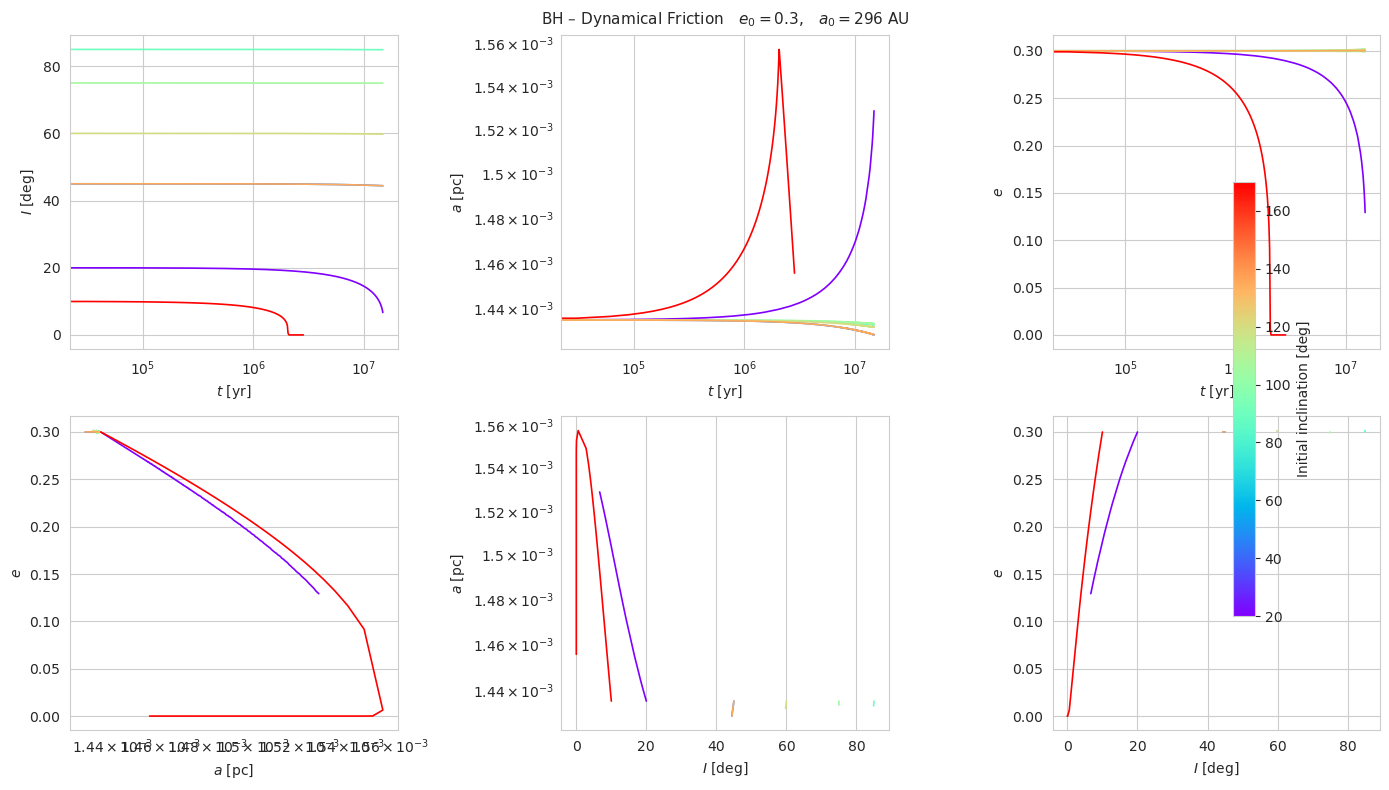

In [6]:
if orbits_low:
    fig_low = plot_trajectories(orbits_low, "BH \u2013 Dynamical Friction", e0=0.3, sma_au=296)
    plt.show()
else:
    print("No ZengLowEcc data found.")

### High Eccentricity (e=0.7, sma=581 AU)

In [7]:
if orbits_high:
    fig_high = plot_trajectories(orbits_high, "BH \u2013 Dynamical Friction", e0=0.7, sma_au=581)
    plt.show()
else:
    print("No ZengHighEcc data found.")

No ZengHighEcc data found.
